In [117]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("D:\\AdamKuchar\\PythonProjekty\\ZSUII\\Titanic-Dataset.csv")
print(df.head())


# Krok 1: Odstránime nepotrebné stĺpce
X = df.drop(['PassengerId', 'Name', 'Survived'], axis=1)
y = df['Survived']

# Vyberieme relevantné stĺpce
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']]

# Nahradíme chýbajúce hodnoty v stĺpci 'Age' priemernou hodnotou
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Nahradíme NaN hodnoty v stĺpci 'Embarked' najčastejšou hodnotou
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


# Zakódujeme kategórie - 'Sex' a 'Embarked'
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})  # zakódovanie Embarked ako numerické

# Rozdelíme dáta na atribúty (X) a cieľovú premennú (y)
X = df.drop('Survived', axis=1)  # Atribúty
y = df['Survived']  # Cieľová premenná (prežitie)

# Krok 4: Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Zobraziť prvé riadky upraveného datasetu
print(X_train.head())




   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [119]:
def mean(values):
    return sum(values) / len(values)

In [120]:
def variance(values,mean):
    return sum([(x-mean)**2 for x in values])/ len(values)

In [121]:

def gaussian_probability(x, mean, var): 
    exponent = math.exp(-((x - mean) ** 2) / (2 * var)) 
    return (1 / math.sqrt(2 * math.pi * var)) * exponent



In [122]:
from sklearn.model_selection import train_test_split




X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [123]:
class NaiveBayes:
    def fit(self,X,y):
        self.classes = set(y) #jedinecne hodntoy
        self.summaries = {}
        for c in self.classes:
            X_c = [X[i] for i in range(len(X)) if y[i] == c]
            features = list(zip(*X_c))
            summaries = []
            for feature in features:
                mean_val = mean(feature)
                var_val = variance(feature, mean_val)
                summaries.append((mean_val, var_val))
            self.summaries[c] = summaries
    def predict(self,X):
        return [self._predict_single(sample) for sample in X]
    
    def _predict_single(self, sample):
        posterior_probs = {}
        for c in self.classes:
            prior = math.log(sum(1 for label in y_train if label == c) / len(y_train))  # P(c)
            likelihood = 0
            for i in range(len(sample)):
                mean_val, var_val = self.summaries[c][i]
                likelihood += math.log(gaussian_probability(sample[i], mean_val, var_val))  # P(x_i | c)
            posterior_probs[c] = prior + likelihood
        
        return max(self.classes, key=lambda c: posterior_probs[c])
            

In [124]:
#X_train = X_train.apply(pd.to_numeric, errors='coerce')
#X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Môžeme teraz pokračovať s trénovaním modelu
model = NaiveBayes()
model.fit(X_train.values, y_train.values)
predictions = model.predict(X_test.values)

accuracy = sum(1 for i in range(len(y_test)) if y_test.values[i] == predictions[i]) / len(y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')


Accuracy: 77.65%


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Ac

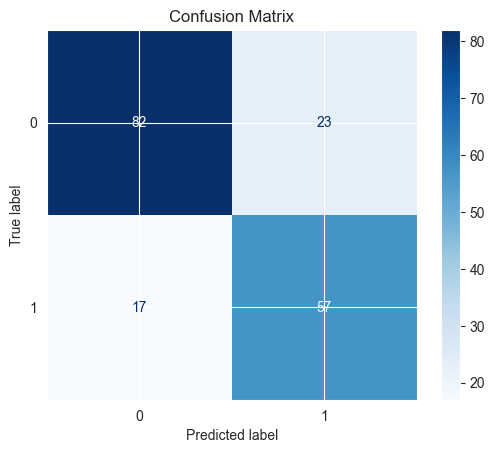

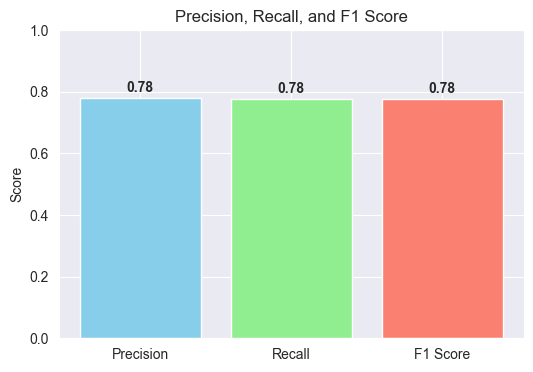

In [125]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

# Načítame Titanic dataset (stiahni si ho zo stránky alebo použijeme URL)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Zobrazíme prvých pár riadkov dát
print(df.head())

# Predspracovanie dát
# Vyberieme relevantné stĺpce
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']]

# Nahradíme chýbajúce hodnoty v stĺpci 'Age' priemernou hodnotou
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Nahradíme NaN hodnoty v stĺpci 'Embarked' najčastejšou hodnotou
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


# Zakódujeme kategórie - 'Sex' a 'Embarked'
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})  # zakódovanie Embarked ako numerické

# Rozdelíme dáta na atribúty (X) a cieľovú premennú (y)
X = df.drop('Survived', axis=1)  # Atribúty
y = df['Survived']  # Cieľová premenná (prežitie)

# Rozdelíme dáta na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vytvoríme model pomocou scikit-learn
sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train, y_train)

# Predikcia pomocou scikit-learn modelu
y_pred_sklearn = sklearn_nb.predict(X_test)

# Presnosť
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f'Accuracy (scikit-learn): {accuracy_sklearn:.4f}')


# Konfúzna matica
cm = confusion_matrix(y_test, y_pred_sklearn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Klasifikačné metriky
precision = precision_score(y_test, y_pred_sklearn, average='weighted')
recall = recall_score(y_test, y_pred_sklearn, average='weighted')
f1 = f1_score(y_test, y_pred_sklearn, average='weighted')

# Zobrazenie metriky Precision, Recall, F1 Score
metrics = ['Precision', 'Recall', 'F1 Score']
values = [precision, recall, f1]

plt.figure(figsize=(6, 4))
plt.bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)
plt.title('Precision, Recall, and F1 Score')
plt.ylabel('Score')

# Zobrazenie hodnôt na grafe
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

NaiveBayes Accuracy: 77.65%
NaiveBayes Fit Time: 0.0064 seconds
NaiveBayes Predict Time: 0.1287 seconds
NaiveBayes Total Time: 0.1352 seconds
Scikit-learn Accuracy: 77.65%
Scikit-learn Fit Time: 0.0030 seconds
Scikit-learn Predict Time: 0.0020 seconds
Scikit-learn Total Time: 0.0050 seconds


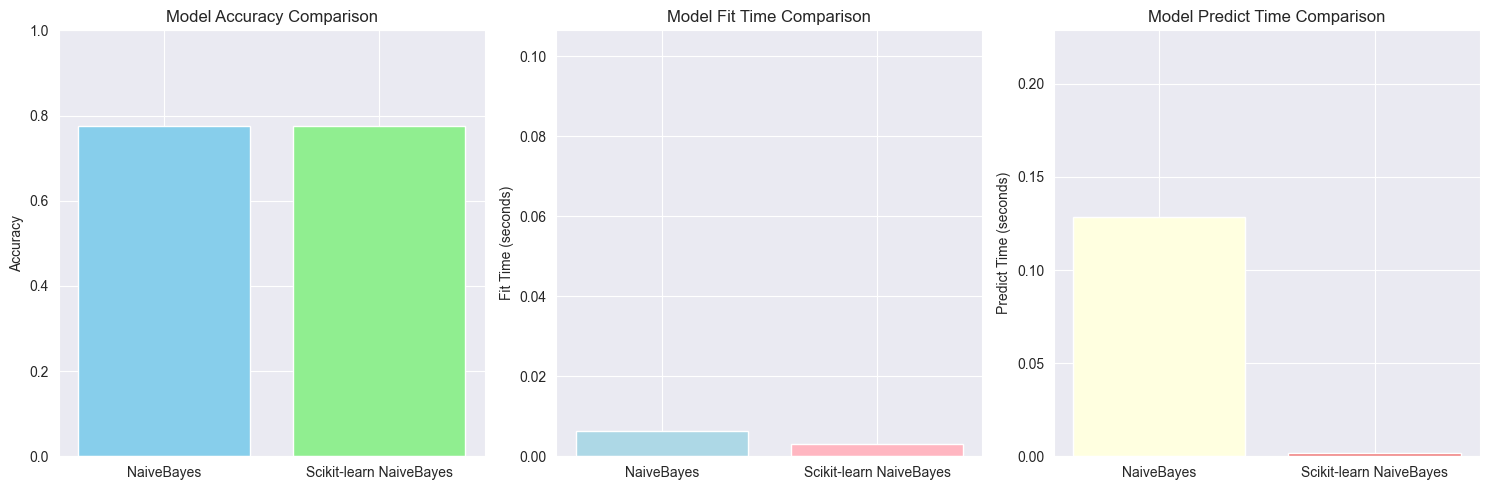

In [127]:
import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

# Časová evaluácia pre NaiveBayes model (vlastný)
start_fit_naivebayes = time.time()
model = NaiveBayes()
model.fit(X_train.values, y_train.values)
fit_naivebayes_time = time.time() - start_fit_naivebayes

start_predict_naivebayes = time.time()
predictions_naivebayes = model.predict(X_test.values)
predict_naivebayes_time = time.time() - start_predict_naivebayes

naivebayes_time = fit_naivebayes_time + predict_naivebayes_time  # Celkový čas pre NaiveBayes

# Vypočítať presnosť pre vlastný model
accuracy_naivebayes = accuracy_score(y_test, predictions_naivebayes)
print(f'NaiveBayes Accuracy: {accuracy_naivebayes * 100:.2f}%')
print(f'NaiveBayes Fit Time: {fit_naivebayes_time:.4f} seconds')
print(f'NaiveBayes Predict Time: {predict_naivebayes_time:.4f} seconds')
print(f'NaiveBayes Total Time: {naivebayes_time:.4f} seconds')

# Časová evaluácia pre sklearn's GaussianNB
start_fit_sklearn = time.time()
sklearn_model = GaussianNB()
sklearn_model.fit(X_train, y_train)
fit_sklearn_time = time.time() - start_fit_sklearn

start_predict_sklearn = time.time()
sklearn_predictions = sklearn_model.predict(X_test)
predict_sklearn_time = time.time() - start_predict_sklearn

sklearn_time = fit_sklearn_time + predict_sklearn_time  # Celkový čas pre sklearn

# Vypočítať presnosť pre knižnicový model
accuracy_sklearn = accuracy_score(y_test, sklearn_predictions)
print(f'Scikit-learn Accuracy: {accuracy_sklearn * 100:.2f}%')
print(f'Scikit-learn Fit Time: {fit_sklearn_time:.4f} seconds')
print(f'Scikit-learn Predict Time: {predict_sklearn_time:.4f} seconds')
print(f'Scikit-learn Total Time: {sklearn_time:.4f} seconds')

# Zobrazenie porovnania času a presnosti
models = ['NaiveBayes', 'Scikit-learn NaiveBayes']
accuracies = [accuracy_naivebayes, accuracy_sklearn]
times = [naivebayes_time, sklearn_time]

# Časy pre fit a predict
fit_times = [fit_naivebayes_time, fit_sklearn_time]
predict_times = [predict_naivebayes_time, predict_sklearn_time]

# Graf presnosti
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

# Graf času pre fit
plt.subplot(1, 3, 2)
plt.bar(models, fit_times, color=['lightblue', 'lightpink'])
plt.ylim(0, max(fit_times) + 0.1)
plt.title('Model Fit Time Comparison')
plt.ylabel('Fit Time (seconds)')

# Graf času pre predict
plt.subplot(1, 3, 3)
plt.bar(models, predict_times, color=['lightyellow', 'lightcoral'])
plt.ylim(0, max(predict_times) + 0.1)
plt.title('Model Predict Time Comparison')
plt.ylabel('Predict Time (seconds)')

# Zobrazenie grafov
plt.tight_layout()
plt.show()
